# Transfer Learning MobileNet

In [1]:
# Import library
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [2]:
# Konfigurasi
DATASET_PATH = r'C:\Users\ACER\Downloads\dump\task\data'
train_dir = os.path.join(DATASET_PATH, 'train')
val_dir = os.path.join(DATASET_PATH, 'val')
test_dir = os.path.join(DATASET_PATH, 'test')

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

### Distribusi Pembagian Dataset

Total gambar di Train: 9169
Total gambar di Validation: 1924
Total gambar di Test: 1924


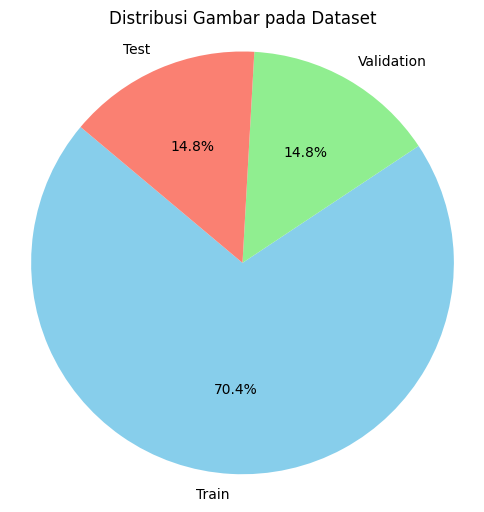

In [3]:
# Fungsi menghitung jumlah gambar di folder (semua subfolder dihitung)
def count_images(directory):
    total = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                total += 1
    return total

# Hitung total gambar otomatis
train_total = count_images(train_dir)
val_total = count_images(val_dir)
test_total = count_images(test_dir)

# Tampilkan jumlah
print(f"Total gambar di Train: {train_total}")
print(f"Total gambar di Validation: {val_total}")
print(f"Total gambar di Test: {test_total}")

# Pie Chart
labels = ['Train', 'Validation', 'Test']
sizes = [train_total, val_total, test_total]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribusi Gambar pada Dataset')
plt.axis('equal')  # Biar bulat
plt.show()


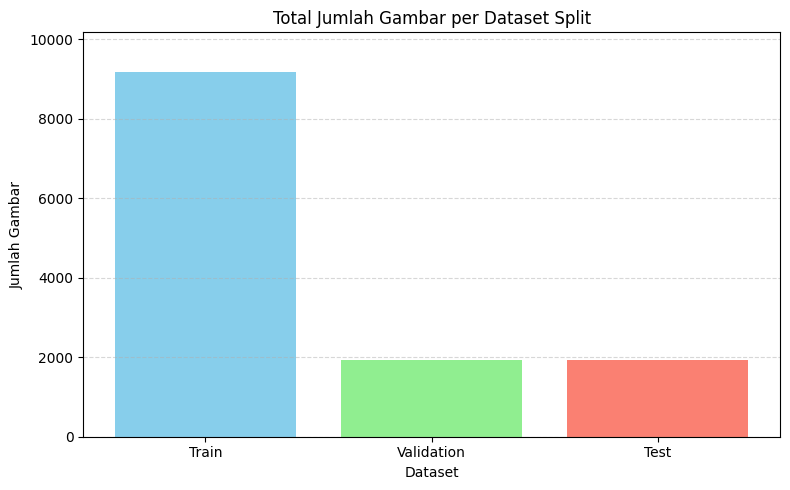

In [4]:
dataset_splits = ['Train', 'Validation', 'Test']
total_counts = [train_total, val_total, test_total]
colors = ['skyblue', 'lightgreen', 'salmon']

# Plot histogram
plt.figure(figsize=(8, 5))
plt.bar(dataset_splits, total_counts, color=colors)
plt.title('Total Jumlah Gambar per Dataset Split')
plt.xlabel('Dataset')
plt.ylabel('Jumlah Gambar')
plt.ylim(0, max(total_counts) + 1000)  # beri ruang di atas
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Sample citra pada data training

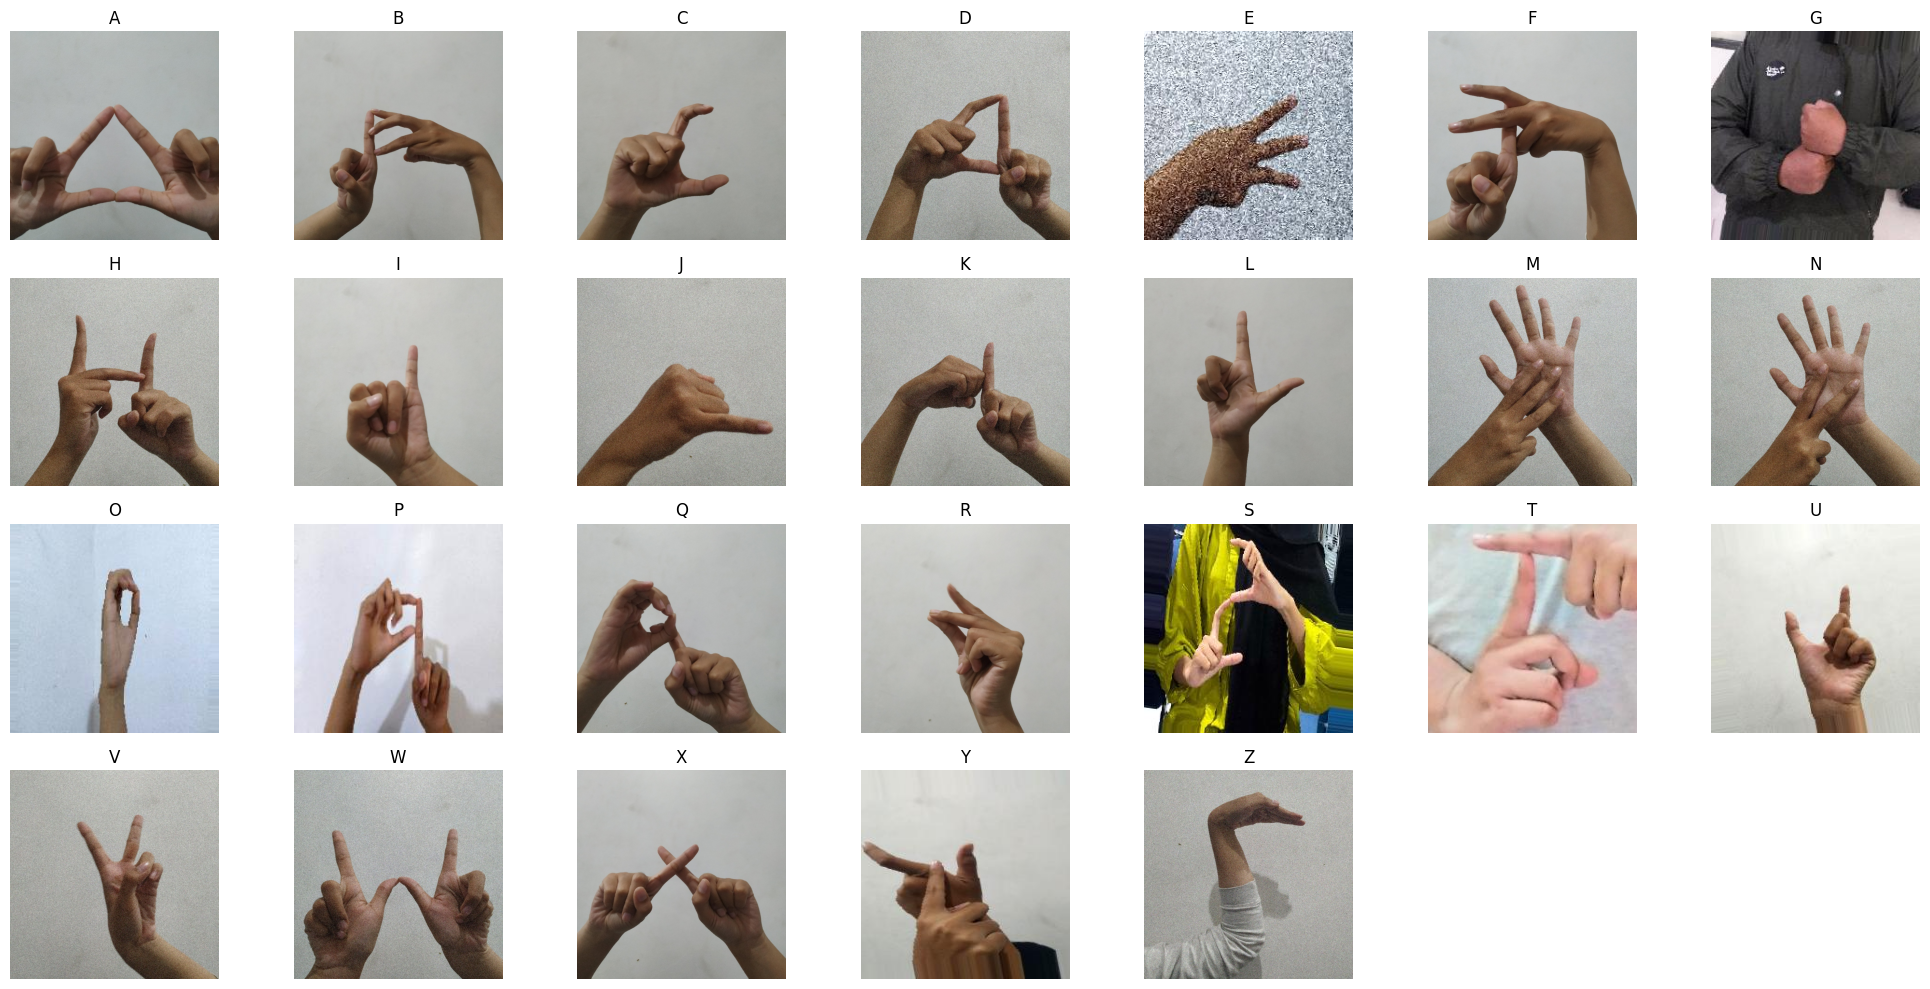

In [5]:
import matplotlib.image as mpimg

# Ambil list semua folder (kelas)
class_folders = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# Buat plot
plt.figure(figsize=(20, 10))

# Loop setiap kelas dan ambil satu gambar
for i, class_name in enumerate(class_folders):
    class_path = os.path.join(test_dir, class_name)
    images = os.listdir(class_path)
    if images:  # Pastikan folder tidak kosong
        img_path = os.path.join(class_path, images[0])  # Ambil gambar pertama
        img = mpimg.imread(img_path)

        # Plot
        plt.subplot(4, 7, i + 1)  # 4 baris, 7 kolom (cocok untuk 26 kelas)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.show()


### Prapemrosesan Dataset dengan Image Data Generator

In [6]:
# ImageDataGenerator untuk augmentasi data
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True,
    rescale=1./255,
    brightness_range=[0.5, 1.5],
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Create training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Create validation generator
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Create testing generator
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 9169 images belonging to 26 classes.
Found 1924 images belonging to 26 classes.
Found 1924 images belonging to 26 classes.


In [8]:
# Perancangan arsitektur CNN dengan base model MobileNetV2
base_model = MobileNet(
    input_shape=(IMG_SIZE,IMG_SIZE,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable=False

# Custom model MobileNet
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global average pooling
x = Flatten()(x)
x = Dense(256, activation='relu')(x)  # Fully connected layer
x = Dropout(0.3)(x)  # Dropout layer to prevent overfitting
outputs = Dense(26, activation='softmax')(x)  # Output layer for 26

# Build the final model
model = Model(inputs=base_model.input, outputs=outputs)

In [9]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,497,946 (13.34 MB)

 Trainable params: 269,082 (1.03 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [11]:
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

# Compile Model 
optimizer = Adam(learning_rate=0.0010)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1Score(name='f1score')
    ]
)


In [12]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
)

C:\Users\ACER\AppData\Roaming\Python\Python39\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 233s 804ms/step - accuracy: 0.5421 - f1score: 0.4829 - loss: 1.7316 - precision: 0.8848 - recall: 0.3562 - val_accuracy: 0.8753 - val_f1score: 0.8863 - val_loss: 0.4164 - val_precision: 0.9811 - val_recall: 0.8082
Epoch 2/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 134s 467ms/step - accuracy: 0.8545 - f1score: 0.8676 - loss: 0.4945 - precision: 0.9553 - recall: 0.7947 - val_accuracy: 0.9267 - val_f1score: 0.9233 - val_loss: 0.2518 - val_precision: 0.9757 - val_recall: 0.8763
Epoch 3/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 138s 479ms/step - accuracy: 0.8967 - f1score: 0.9033 - loss: 0.3253 - precision: 0.9536 - recall: 0.8582 - val_accuracy: 0.9428 - val_f1score: 0.9392 - val_loss: 0.1973 - val_precision: 0.9775 - val_recall: 0.9038
Epoch 4/100
287/287 ━━━━━━━━━━━━━━━━━━━━ 135s 472ms/step - accuracy: 0.9150 - f1score: 0.9172 - loss: 0.2695 - precision: 0.9582 - recall: 0.8795 - val_accuracy: 0.9475 - val_f1score: 0.9489 - val_loss: 0.1756 - val_precision: 0.9727 -

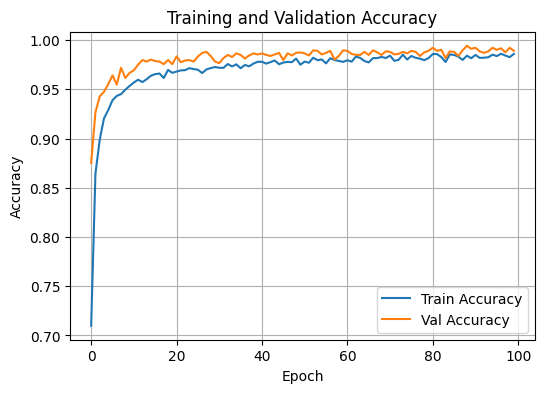

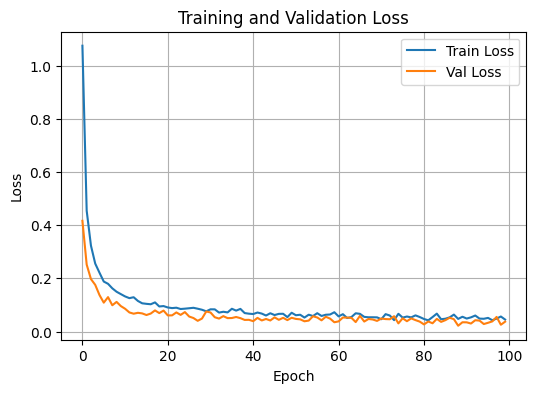

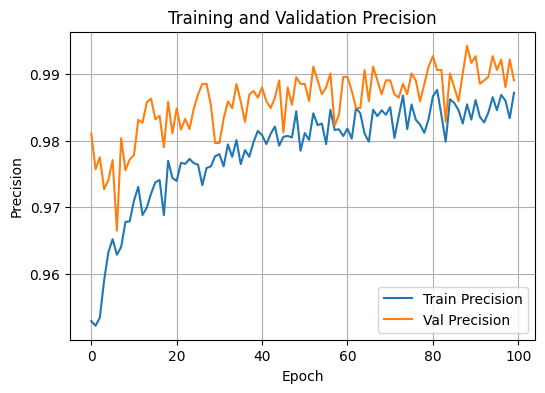

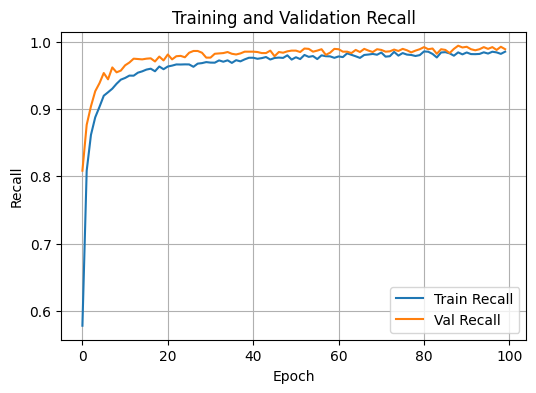

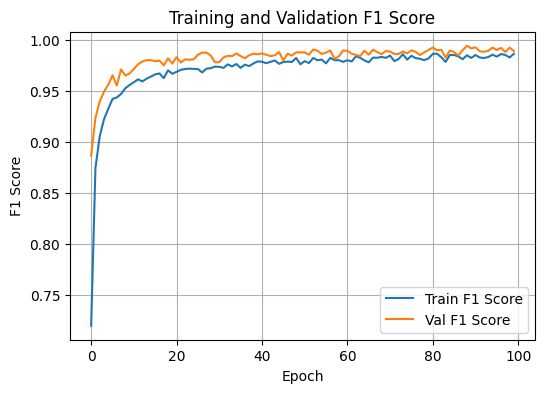

In [14]:
import matplotlib.pyplot as plt

# Grafik 1: Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 2: Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 3: Precision
plt.figure(figsize=(6, 4))
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.title('Training and Validation Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 4: Recall
plt.figure(figsize=(6, 4))
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Training and Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 5: F1 Score
plt.figure(figsize=(6, 4))
plt.plot(history.history['f1score'], label='Train F1 Score')
plt.plot(history.history['val_f1score'], label='Val F1 Score')
plt.title('Training and Validation F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
# Evaluasi model
loss, accuracy, precision, recall, f1_score = model.evaluate(val_generator)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1_Score: {f1_score}")


61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - accuracy: 0.9925 - f1score: 0.9923 - loss: 0.0182 - precision: 0.9925 - recall: 0.9921
Loss: 0.037148792296648026
Accuracy: 0.9890852570533752
Precision: 0.9890795350074768
Recall: 0.9885655045509338
F1_Score: 0.9888224005699158


In [16]:
# Menyimpan model setelah pelatihan selesai
model.save('mobilenet_bs32_is224_ep100_lr1e-3.keras')

In [17]:
from tensorflow.keras.metrics import Metric
from tensorflow.keras import backend as K
from keras.saving import register_keras_serializable

@register_keras_serializable()
class F1Score(Metric):
    def __init__(self, name='f1score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()
        

model = tf.keras.models.load_model(
    r"C:\Users\ACER\Downloads\dump\task\mobilenet_bs32_is224_ep100_lr1e-3.keras",
    custom_objects={'F1Score': F1Score}
)



In [19]:
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Ambil ground truth label
y_true = val_generator.classes

# Ambil prediksi dari model
y_pred_prob = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Hitung metric global manual
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(val_generator.class_indices.keys())))

61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 237ms/step
Accuracy:  0.9891
Precision: 0.9894
Recall:    0.9891
F1 Score:  0.9891

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        74
           B       1.00      0.99      0.99        74
           C       1.00      1.00      1.00        74
           D       1.00      1.00      1.00        74
           E       1.00      1.00      1.00        74
           F       1.00      1.00      1.00        74
           G       0.99      1.00      0.99        74
           H       1.00      1.00      1.00        74
           I       1.00      0.99      0.99        74
           J       1.00      0.97      0.99        74
           K       1.00      1.00      1.00        74
           L       0.97      0.99      0.98        74
           M       0.97      0.89      0.93        74
           N       0.90      0.97      0.94        74
           O       1.00      1.00      1.00       

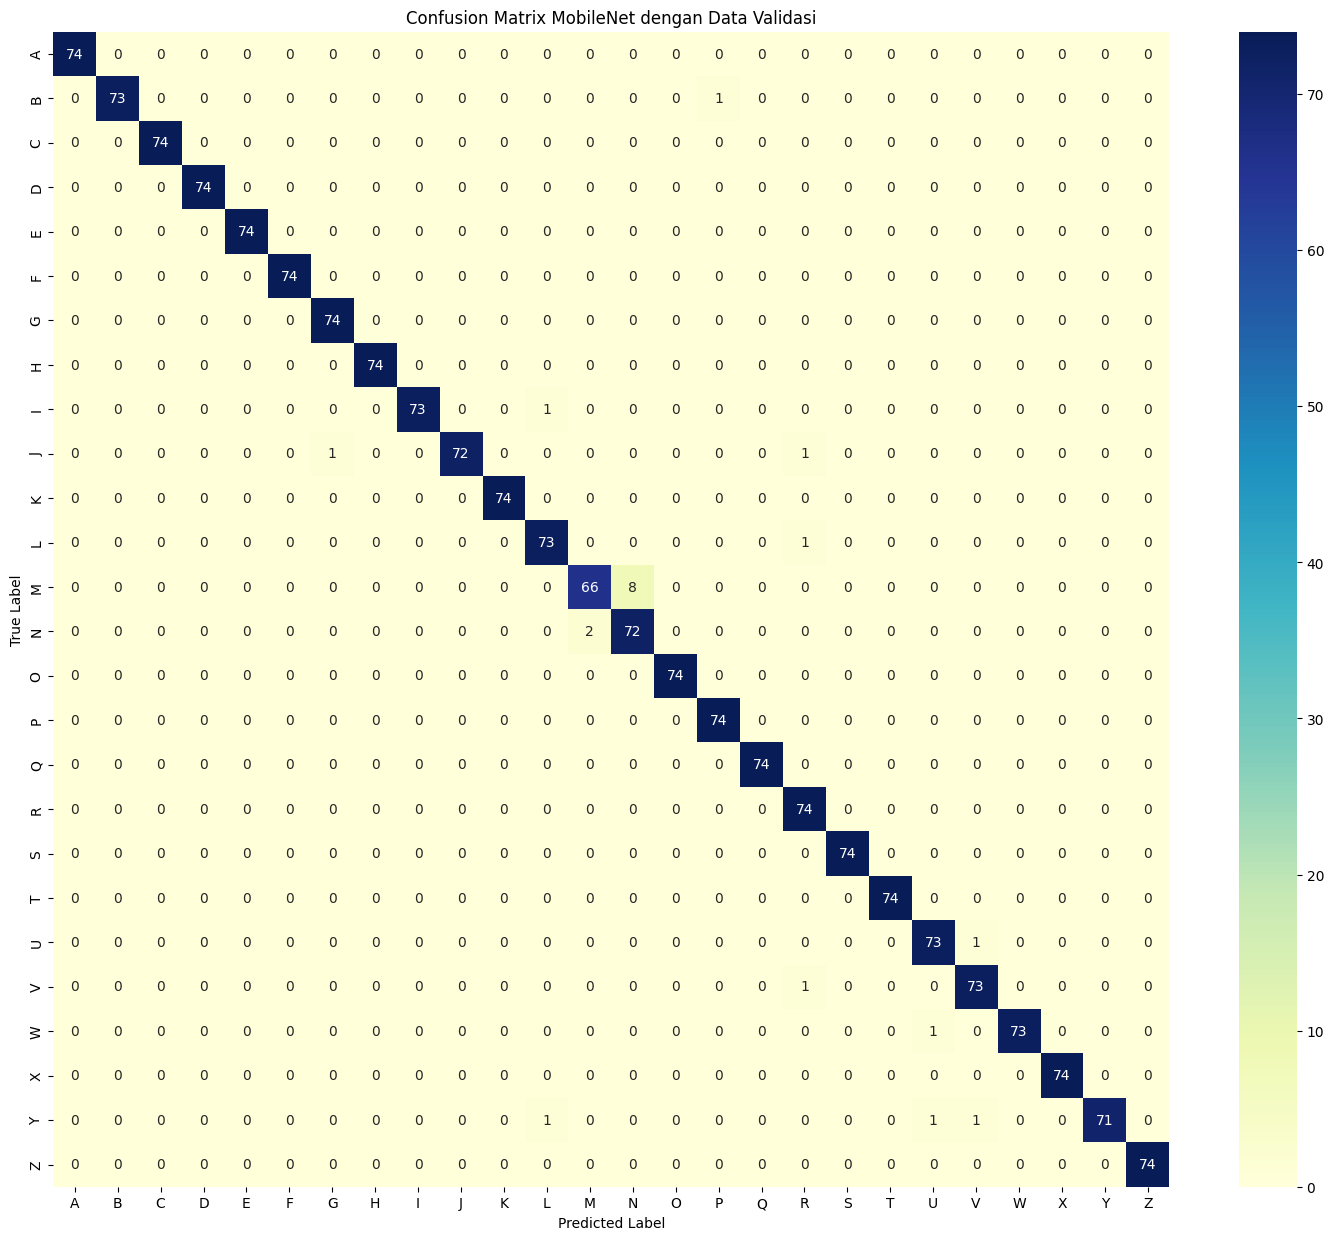

In [20]:
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.metrics import confusion_matrix  
import string  


# Label nama kelas A-Z
labels = list(string.ascii_uppercase)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix MobileNet dengan Data Validasi')
plt.show()


In [21]:
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Ambil ground truth label
y_true = test_generator.classes

# Ambil prediksi dari model
y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Hitung metric global manual
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

C:\Users\ACER\AppData\Roaming\Python\Python39\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 475ms/step
Accuracy:  0.9740
Precision: 0.9748
Recall:    0.9740
F1 Score:  0.9741

Classification Report:

              precision    recall  f1-score   support

           A       0.96      1.00      0.98        74
           B       1.00      1.00      1.00        74
           C       0.95      0.99      0.97        74
           D       0.95      0.96      0.95        74
           E       0.99      1.00      0.99        74
           F       0.89      1.00      0.94        74
           G       0.99      0.99      0.99        74
           H       1.00      0.99      0.99        74
           I       0.99      0.99      0.99        74
           J       0.99      0.99      0.99        74
           K       1.00      0.95      0.97        74
           L       0.97      0.97      0.97        74
           M       0.93      0.95      0.94        74
           N       0.93      0.95      0.94        74
           O       1.00      1.00      1.00       

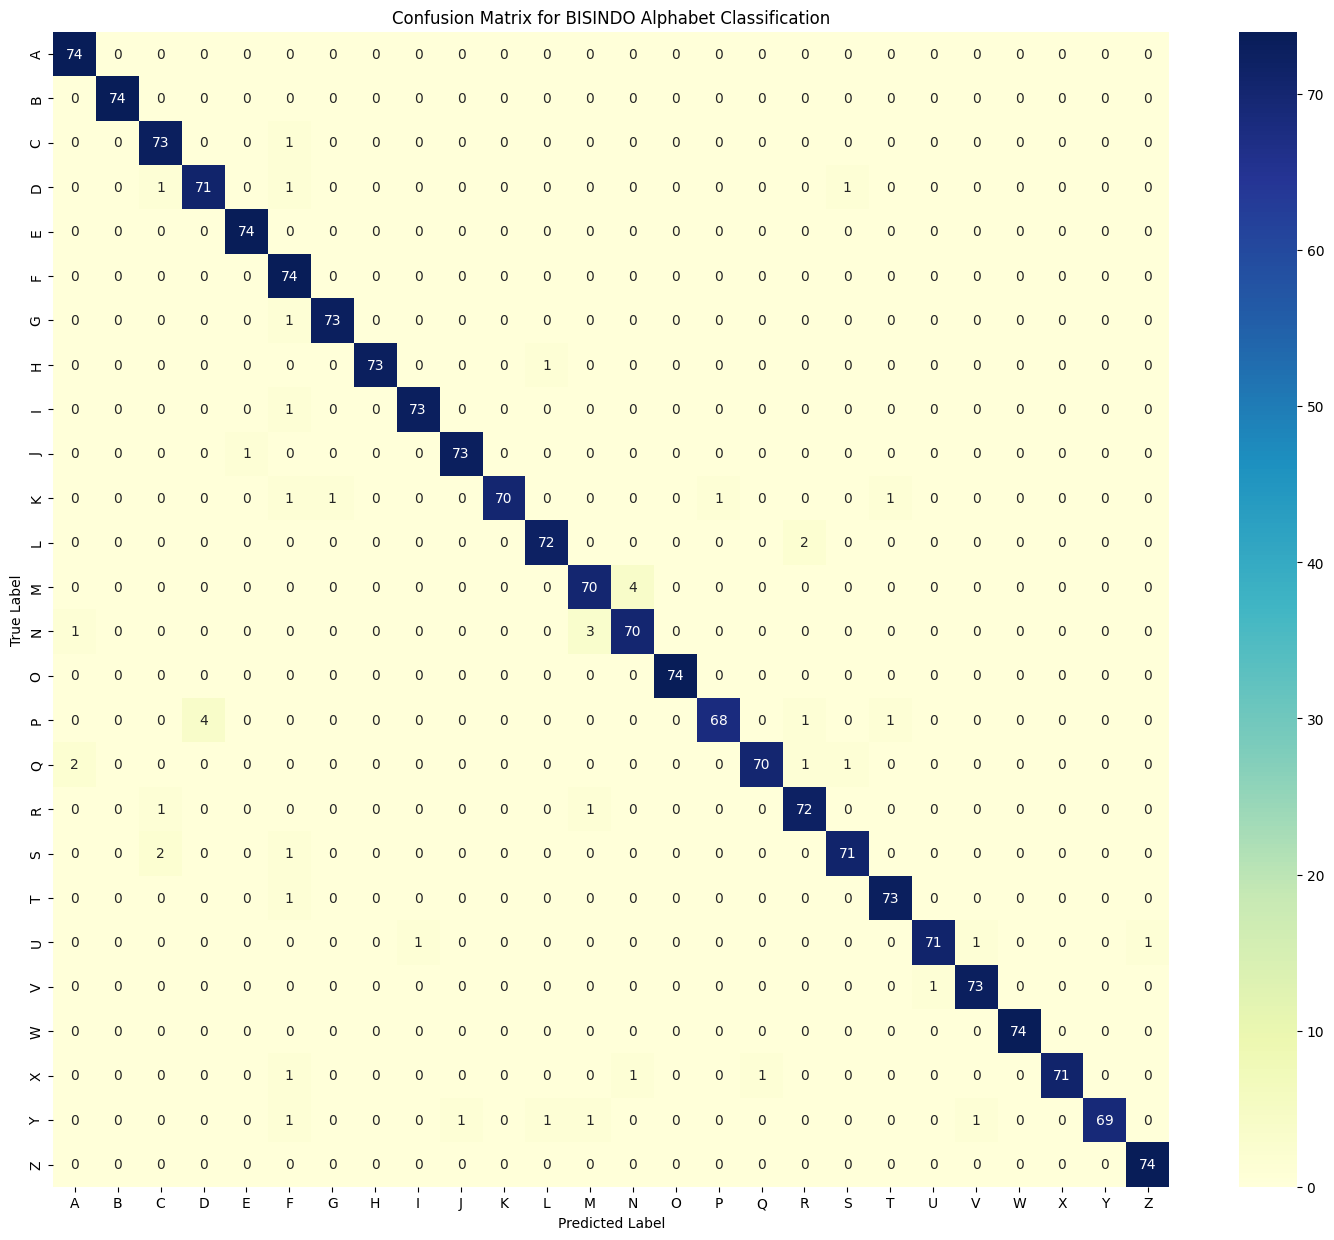

In [22]:
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.metrics import confusion_matrix  
import string  


# Label nama kelas A-Z
labels = list(string.ascii_uppercase)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for BISINDO Alphabet Classification')
plt.show()


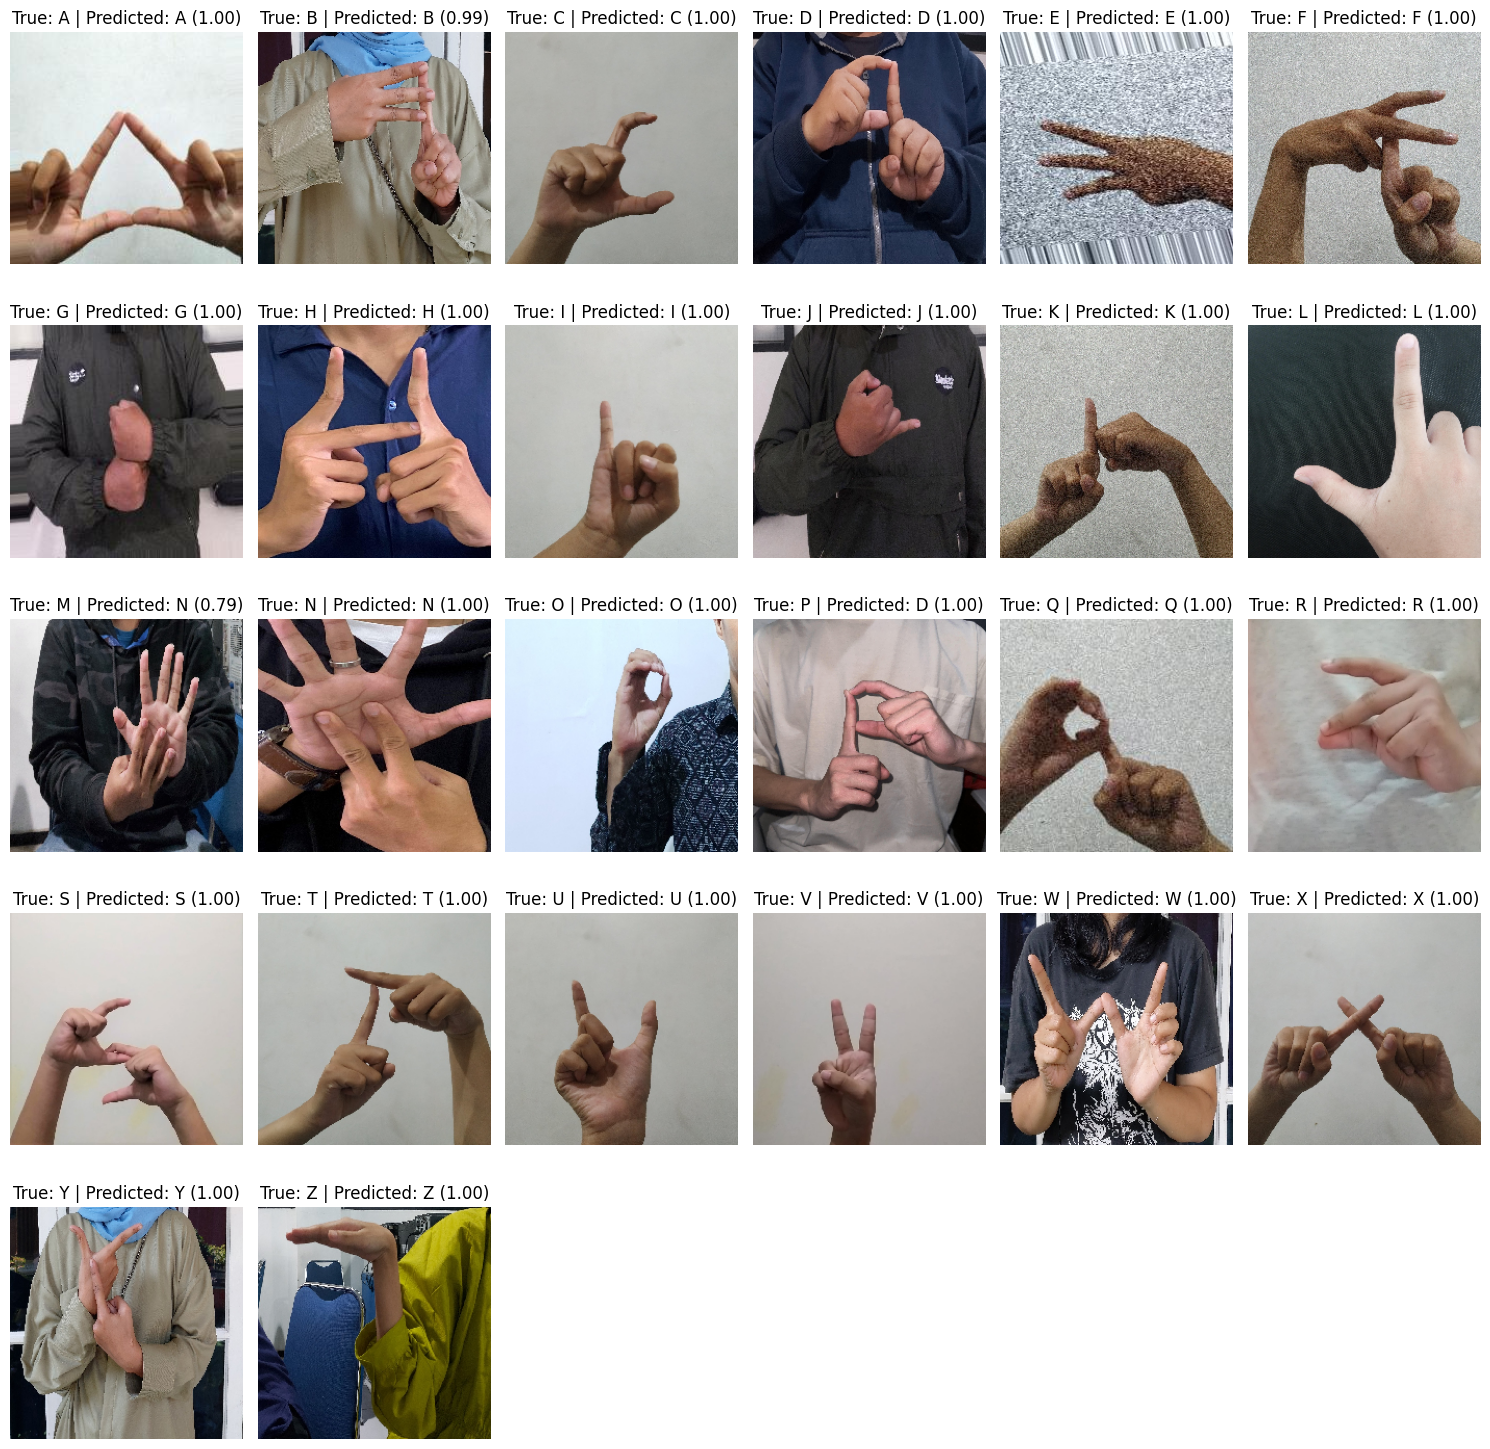

In [24]:
import random
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Metric
import tensorflow as tf
from keras.saving import register_keras_serializable

# === Definisi F1Score Custom ===
@register_keras_serializable()
class F1Score(Metric):
    def __init__(self, name='f1score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

# === Konfigurasi ===
model_path = r'C:\Users\ACER\Downloads\dump\task\mobilenet_bs32_is224_ep100_lr1e-3.keras'
image_folder = r'C:\Users\ACER\Downloads\dump\task\data\test'
img_size = (224, 224)

# === Load model dengan custom_objects ===
model = load_model(model_path, custom_objects={'F1Score': F1Score})
class_names = sorted(os.listdir(image_folder))

# === Fungsi prediksi dan visualisasi ===
def predict_and_plot(folder_path, true_label):
    images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not images:
        return False
    img_file = random.choice(images)
    img_path = os.path.join(folder_path, img_file)

    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction)
    predicted_label = class_names[predicted_index]
    confidence = np.max(prediction)

    plt.imshow(img)
    plt.title(f"True: {true_label} | Predicted: {predicted_label} ({confidence:.2f})")
    plt.axis('off')
    return True

# === Visualisasi hasil prediksi satu gambar per folder ===
plt.figure(figsize=(15, 15))
rows = 5
cols = 6

i = 1
for label_folder in class_names:
    folder_path = os.path.join(image_folder, label_folder)
    if os.path.isdir(folder_path):
        plt.subplot(rows, cols, i)
        success = predict_and_plot(folder_path, label_folder)
        if success:
            i += 1
        if i > rows * cols:
            break

plt.tight_layout()
plt.show()
